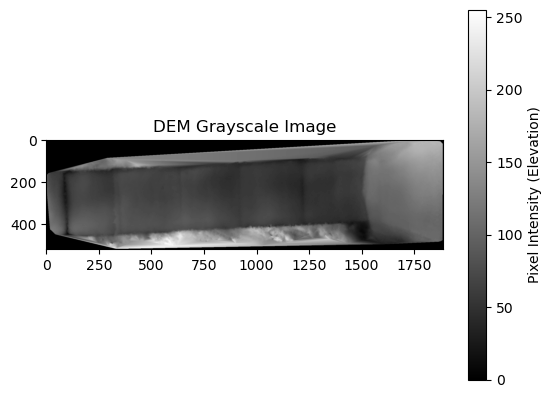

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the grayscale DEM image
image_path = r"C:\pointcloud_files\Demo\sidewalk_1\sidewalk_1DEM.jpg"  # Use raw string (r"...") to avoid escape issues
dem_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display the DEM image
plt.imshow(dem_image, cmap='gray')
plt.colorbar(label="Pixel Intensity (Elevation)")
plt.title("DEM Grayscale Image")
plt.show()

In [2]:
# Define the known min and max elevations (example values)
min_elevation = 0  # Minimum real-world elevation
max_elevation = 0.3  # Maximum real-world elevation

# Normalize the pixel values to real-world elevation
elevation_data = (dem_image / 255) * (max_elevation - min_elevation) + min_elevation

# Get min/max elevation from image
print("Min Elevation:", np.min(elevation_data), "meters")
print("Max Elevation:", np.max(elevation_data), "meters")


Min Elevation: 0.0 meters
Max Elevation: 0.3 meters


In [3]:
x, y = 100, 300  # Example coordinates
elevation_value = elevation_data[y, x]  # Note: OpenCV uses (y, x) indexing
print(f"Elevation at ({x}, {y}): {elevation_value} meters")


Elevation at (100, 300): 0.04 meters


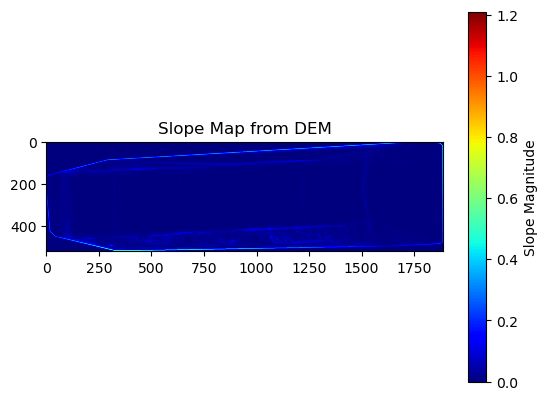

In [4]:
import scipy.ndimage

dx = scipy.ndimage.sobel(elevation_data, axis=1)  # Gradient in X direction
dy = scipy.ndimage.sobel(elevation_data, axis=0)  # Gradient in Y direction
slope = np.hypot(dx, dy)  # Compute slope magnitude

# Show the slope map
plt.imshow(slope, cmap='jet')
plt.colorbar(label="Slope Magnitude")
plt.title("Slope Map from DEM")
plt.show()
